In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.cluster import AgglomerativeClustering

In [2]:
df = pd.read_csv("smartcart_customers.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [3]:
# handle missing data 
imputer = SimpleImputer(strategy = "mean")
df["Income"] = imputer.fit_transform(df[["Income"]])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
# Feature Engineering
df["Age"] = 2026 - df["Year_Birth"]
df["Education"] = df["Education"].replace({
    "Graduation":"Graduate",
    "Basic":"Under_Graduate",
    "2n Cycle":"Under_Graduate",
    "Master" : "Post_Graduate",
    "PhD" : "Post_Graduate"
})
# Total Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] +df["MntFishProducts"]+df["MntSweetProducts"] +df["MntGoldProds"]


In [5]:
# children
df["Children"] = df["Kidhome"] + df["Teenhome"]
# Dt_date to Tenure Days
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst =True)
reference_date = np.max(df["Dt_Customer"])
df["Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [6]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Widow":"Alone",
    "Absurd":"Alone",
    "YOLO":"Alone"
}) 

In [7]:
#  droping columns
col = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
clean_df = df.drop(col ,axis =1)
# clean_df.shape
clean_df.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Total_Spending,Children,Tenure_Days,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,1617,0,663,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,27,2,113,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,776,0,312,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,53,1,139,Partner
4,Post_Graduate,58293.0,94,5,5,3,6,5,0,0,45,422,1,161,Partner


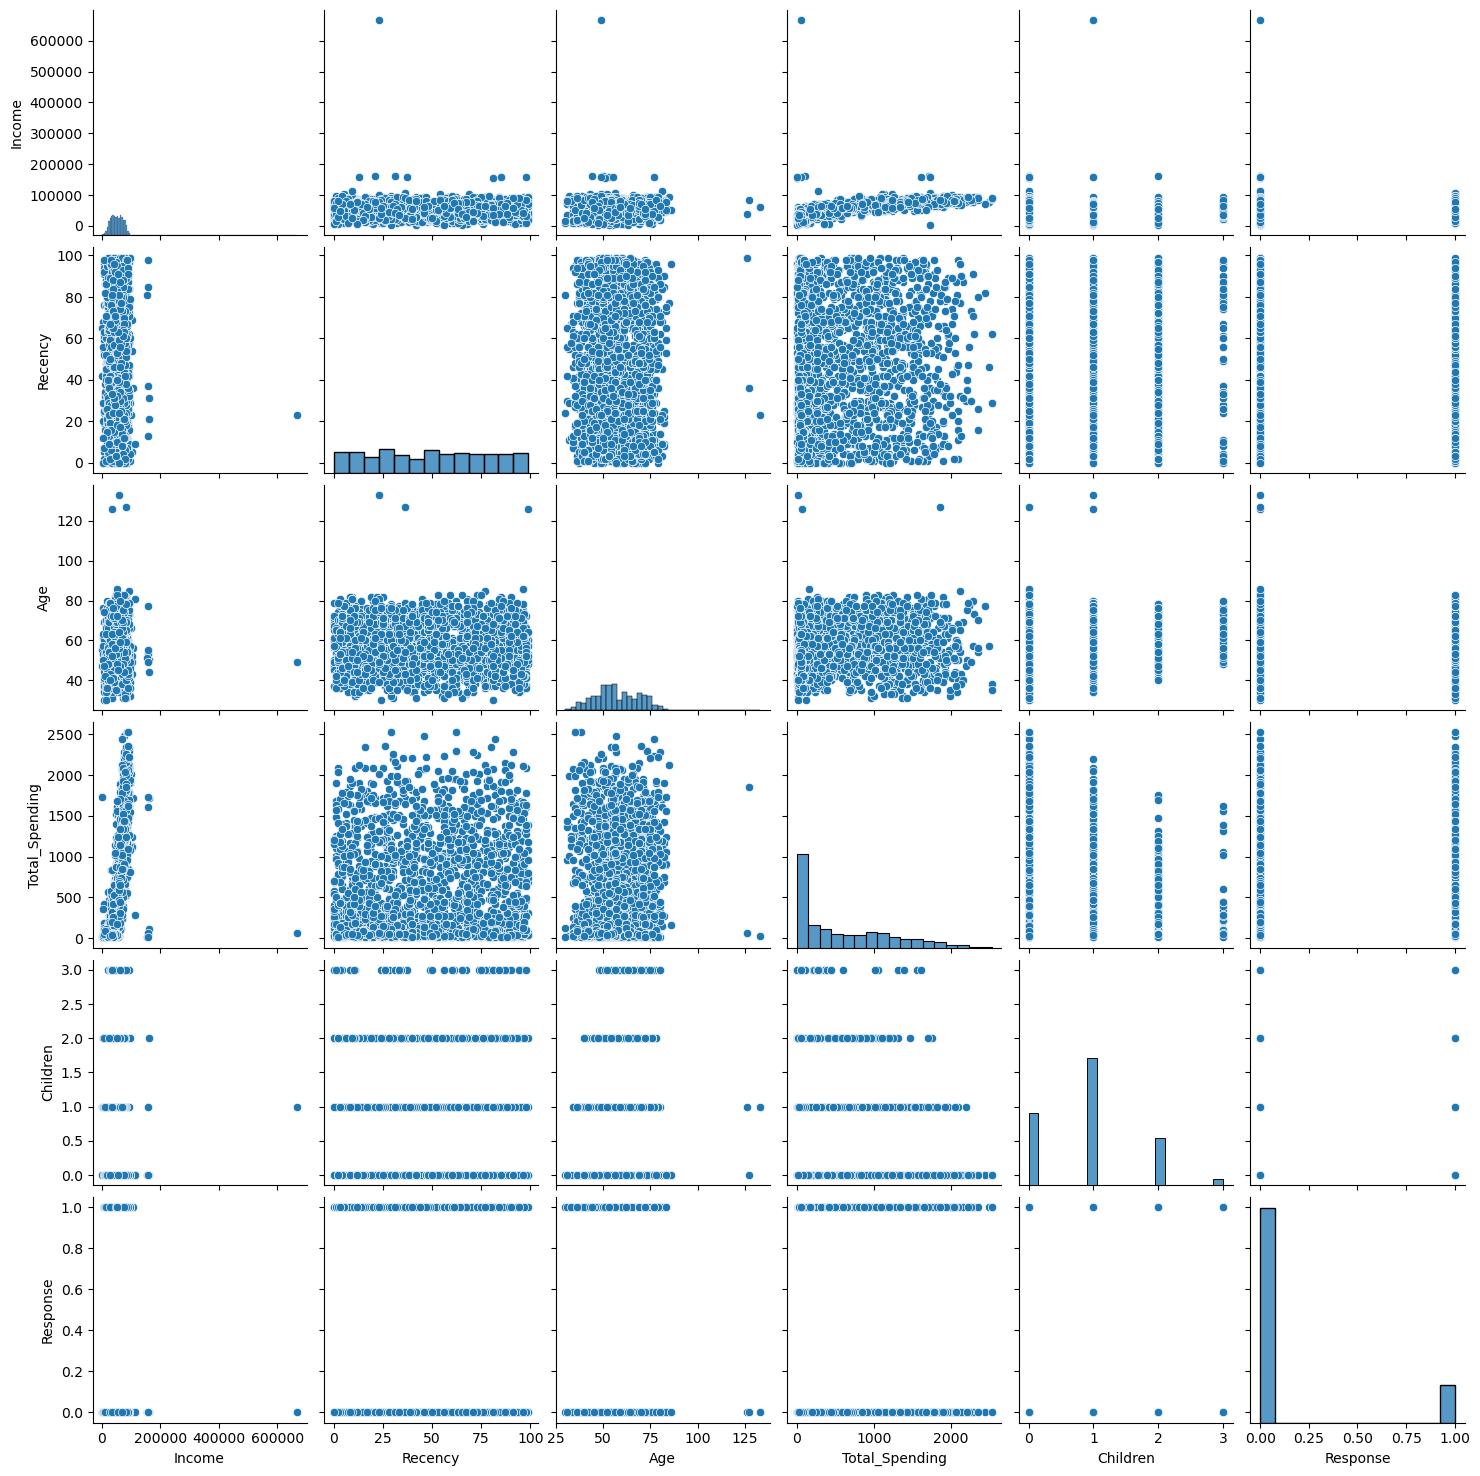

In [8]:
# outliers
cols = ["Income","Recency","Age","Total_Spending","Children","Response"]
sns.pairplot(clean_df[cols])

In [9]:
# removing outliers
clean_df = clean_df[clean_df["Age"]<90]
clean_df = clean_df[clean_df["Income"] <600000]
clean_df.shape

(2236, 15)

In [10]:
# Encoding
cat_col = ["Education","Living_With"]
encoder = OneHotEncoder()
enc_col = encoder.fit_transform(clean_df[cat_col])
enc_coldf = pd.DataFrame(enc_col.toarray(),columns =encoder.get_feature_names_out(cat_col),index = clean_df.index )
encoded_df = pd.concat([clean_df.drop(columns=cat_col),enc_coldf],axis=1)
encoded_df

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Total_Spending,Children,Tenure_Days,Education_Graduate,Education_Post_Graduate,Education_Under_Graduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,1617,0,663,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,27,2,113,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,776,0,312,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,53,1,139,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,422,1,161,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,1341,1,381,1.0,0.0,0.0,0.0,1.0
2236,64014.0,56,7,8,2,5,7,0,0,80,444,3,19,0.0,1.0,0.0,0.0,1.0
2237,56981.0,91,1,2,3,13,6,0,0,45,1241,0,155,1.0,0.0,0.0,1.0,0.0
2238,69245.0,8,2,6,5,10,3,0,0,70,843,1,156,0.0,1.0,0.0,0.0,1.0


<Axes: >

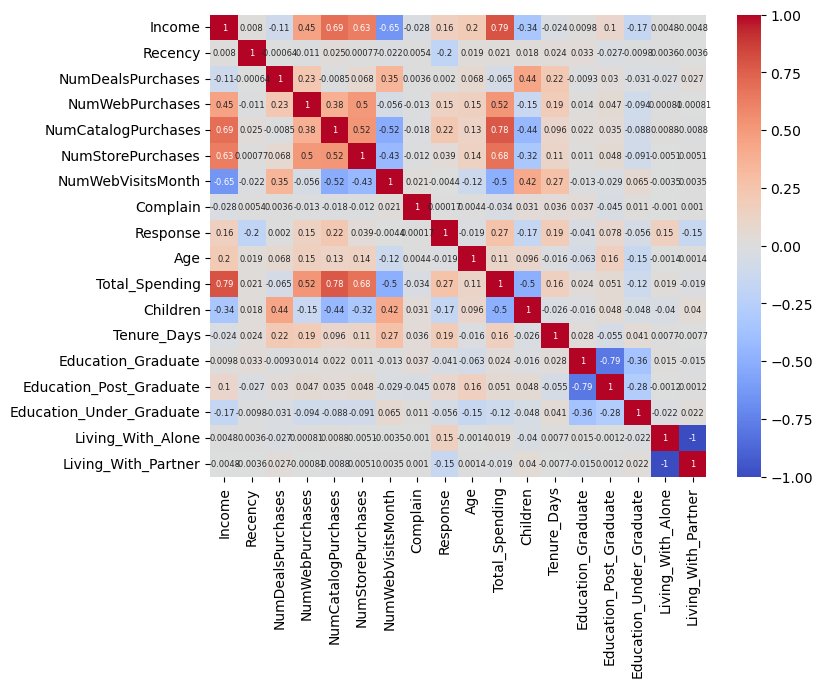

In [11]:
# Heatmap Relations
corr = encoded_df.corr(numeric_only = True)
plt.figure(figsize = (8,6))
sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size":6},
    cmap = "coolwarm"
)

In [12]:
# Scaling data
X = encoded_df
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.2885133 ,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.26243786, -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91799157, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.23446459,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80737157, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04237444, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]])

In [13]:
pca =PCA(n_components = 3,random_state=42)
x_pca = pca.fit_transform(X_scaled)
# Print explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))

Explained variance ratio: [0.23162286 0.11385437 0.1040582 ]
Cumulative explained variance: [0.23162286 0.34547723 0.44953543]


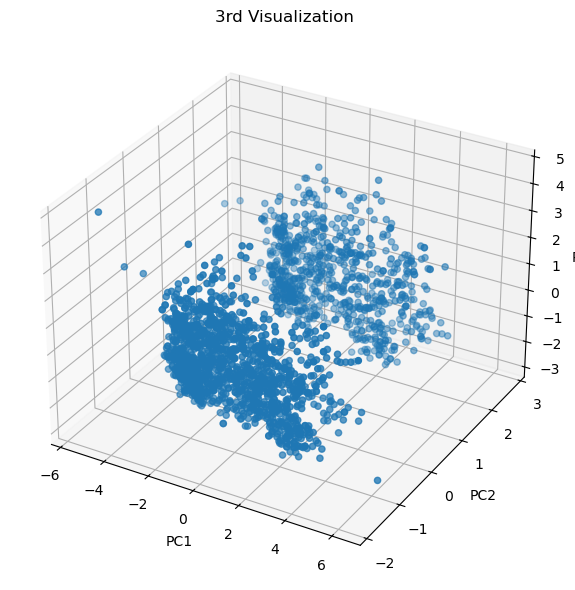

In [14]:
# 3rd visualization
fig =plt.figure(figsize =(6,6))
ax = fig.add_subplot(111, projection='3d') 

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title("3rd Visualization")
plt.tight_layout()
plt.show()

In [15]:
# choosing k 
wcss= []

for k in range(1,11):
    kmeans =KMeans(n_clusters = k ,random_state =42)
    kmeans.fit(x_pca)
    wcss.append(kmeans.inertia_)

kneed = KneeLocator(x=range(1,11),y=wcss,curve="convex",direction = "decreasing")

optimal_k = kneed.knee



E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

In [16]:
print("optimal K : ",optimal_k)

optimal K :  4


In [17]:
b_kmean = KMeans(n_clusters = 4,random_state =42)
labels = b_kmean.fit_predict(x_pca)

E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


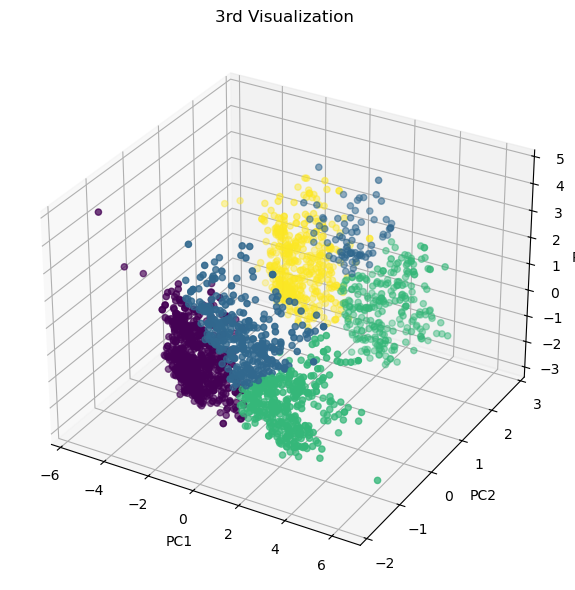

In [18]:
# 3rd visualization
fig =plt.figure(figsize =(6,6))
ax = fig.add_subplot(111, projection='3d') 

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title("3rd Visualization")
plt.tight_layout()
plt.show()

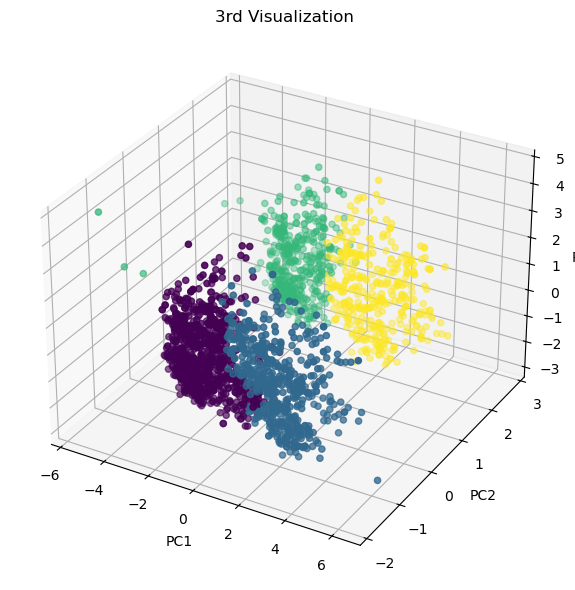

In [19]:
# Agglomerative
agg = AgglomerativeClustering(n_clusters = 4,linkage = "ward")
agg_labels = agg.fit_predict(x_pca)
# 3rd visualization
fig =plt.figure(figsize =(6,6))
ax = fig.add_subplot(111, projection='3d') 

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=agg_labels)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title("3rd Visualization")
plt.tight_layout()
plt.show()

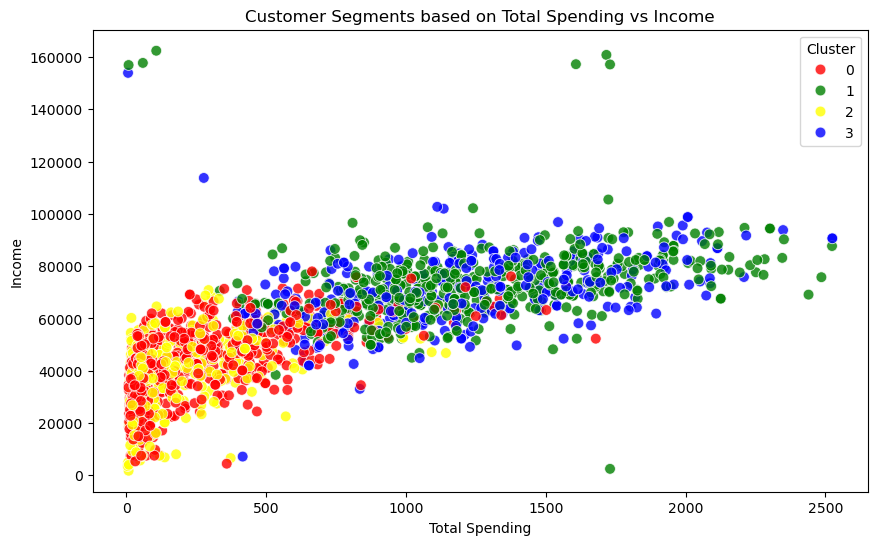

In [20]:
# best model for this data is Agglomerative
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df, 
    x="Total_Spending", 
    y="Income", 
    hue=agg_labels,          # Color by cluster labels
    palette=["red", "green", "yellow", "blue"],   # Custom colors
    s=60,                    # Size of points
    alpha=0.8                # Transparency
)

plt.title("Customer Segments based on Total Spending vs Income")
plt.xlabel("Total Spending")
plt.ylabel("Income")
plt.legend(title="Cluster")
plt.show()

In [27]:
# clusters summary 
X["clusters"] = agg_labels
cluster_summary  = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39690.146424  48.914917           2.594475         3.153591   
1         72814.930722  49.202247           1.958801         5.687266   
2         36973.792251  48.319820           2.594595         2.713964   
3         70730.038963  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Total_Spending  Children  Tenure_Days  \
cl